In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import same_start as sst
import steady_state as ss

RECORDINGS = Path("../../Assets/SimulationRecordings/Combinations/20260825_014231")

runs = sst.load_folder(RECORDINGS)
inv = sst.inventory(runs)

SPEED = inv["speeds"][0]     # the figures below are per max speed; 
RADII = inv["radii"]

print(f"{len(runs)} clips from {RECORDINGS.name}\n")
print(sst.describe(inv))

390 clips from 20260825_014231

random movement : 0, 40, 80
max speed       : 1.5, 4
perception radii: 13 levels, 0.15 to 3.5
                  0.15, 0.45, 0.9, 1.15, 1.5, 1.8, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5
spawn layouts   : 5  (all shared by every condition)

   motion         random  maxSpeed  clips  layouts  radii  R range
   Dispersion          0       1.5     65        5     13  0.15-3.5
   Dispersion          0       4.0     65        5     13  0.15-3.5
   Dispersion         40       1.5     65        5     13  0.15-3.5
   Dispersion         40       4.0     65        5     13  0.15-3.5
   Dispersion         80       1.5     65        5     13  0.15-3.5
   Dispersion         80       4.0     65        5     13  0.15-3.5


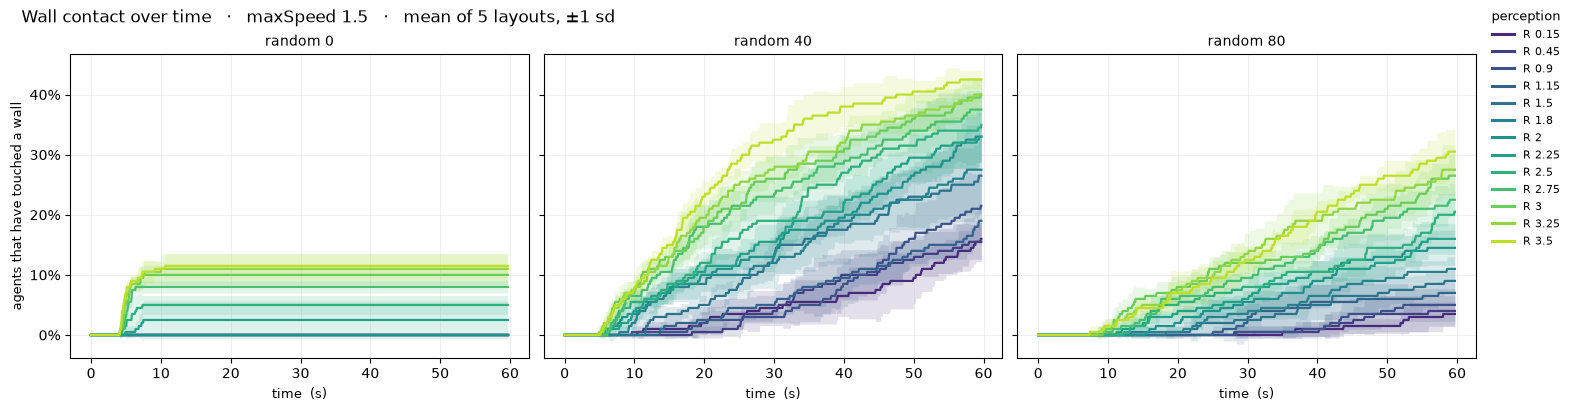

In [2]:
sst.mean_series_figure(runs, SPEED, metric="walls")
plt.show()

In [3]:
budget = 0.20
rows = []
for run in runs:
    n = max(int(run["header"].get("agentCount", 1)), 1)
    rows.append({"maxSpeed": run["speed"], "random": run["random"], "R": run["R"],
                 "touched": run["unique"][-1] / n})

walls = (pd.DataFrame(rows).groupby(["maxSpeed", "random", "R"])["touched"]
           .mean().unstack("R").round(2))
print(f"share of the swarm that touched a wall by the end of the clip  (budget {budget:.0%})")
display(walls)

share of the swarm that touched a wall by the end of the clip  (budget 20%)


R                0.15  0.45  0.90  1.15  1.50  1.80  2.00  2.25  2.50  2.75  \
maxSpeed random                                                               
1.5      0       0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.02  0.05  0.08   
         40      0.16  0.16  0.22  0.19  0.26  0.28  0.33  0.33  0.35  0.38   
         80      0.04  0.04  0.05  0.07  0.09  0.11  0.14  0.16  0.20  0.22   
4.0      0       0.00  0.00  0.00  0.00  0.00  0.02  0.04  0.07  0.08  0.11   
         40      0.68  0.68  0.74  0.70  0.72  0.68  0.70  0.70  0.73  0.68   
         80      0.88  0.88  0.92  0.88  0.92  0.88  0.87  0.88  0.89  0.88   

R                3.00  3.25  3.50  
maxSpeed random                    
1.5      0       0.10  0.11  0.12  
         40      0.40  0.40  0.42  
         80      0.26  0.28  0.30  
4.0      0       0.14  0.18  0.20  
         40      0.68  0.64  0.66  
         80      0.84  0.86  0.86

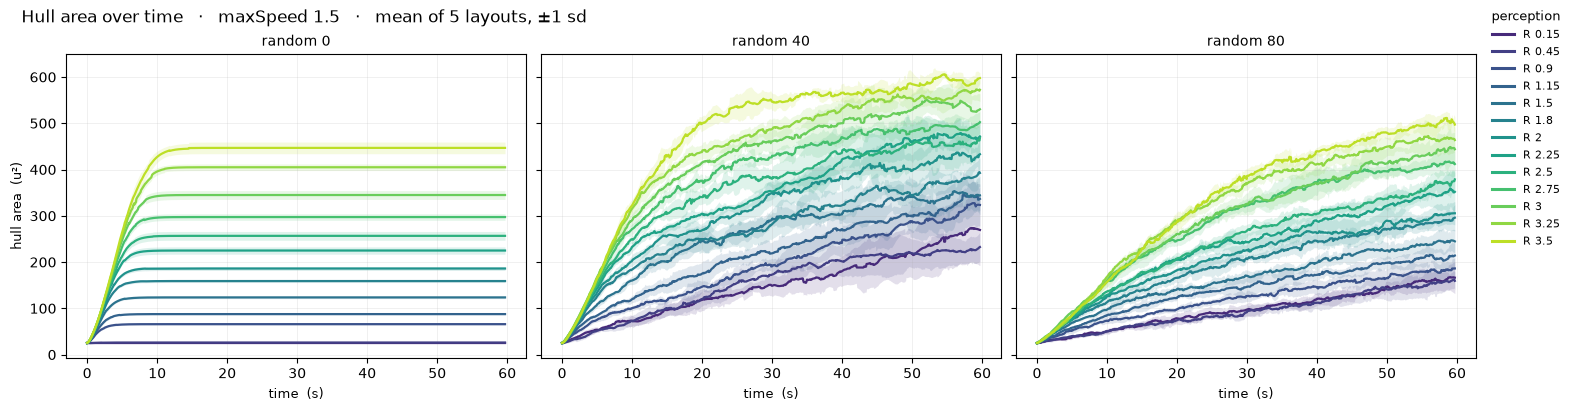

In [4]:
sst.mean_series_figure(runs, SPEED, metric="hull")
plt.show()

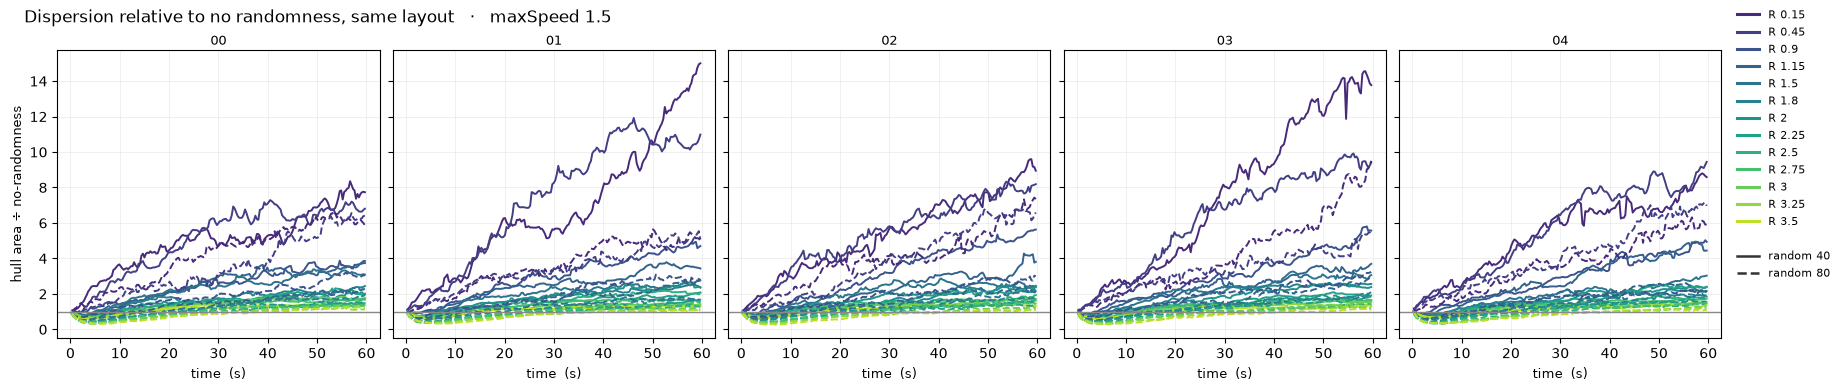

In [5]:
sst.reference_figure(runs, SPEED, mode="ratio")
plt.show()

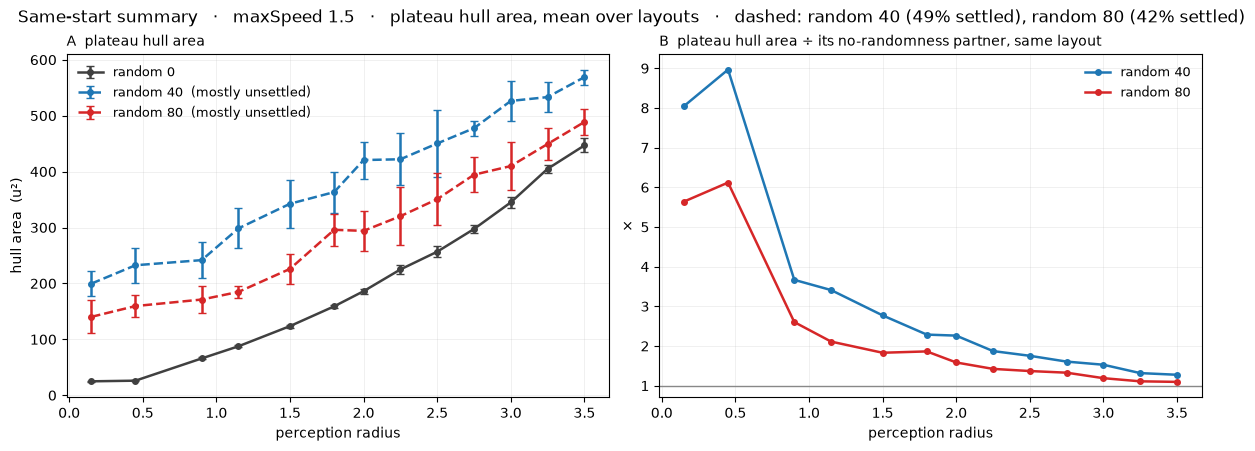

In [6]:
sst.summary_figure(runs, SPEED, statistic="plateau")
plt.show()

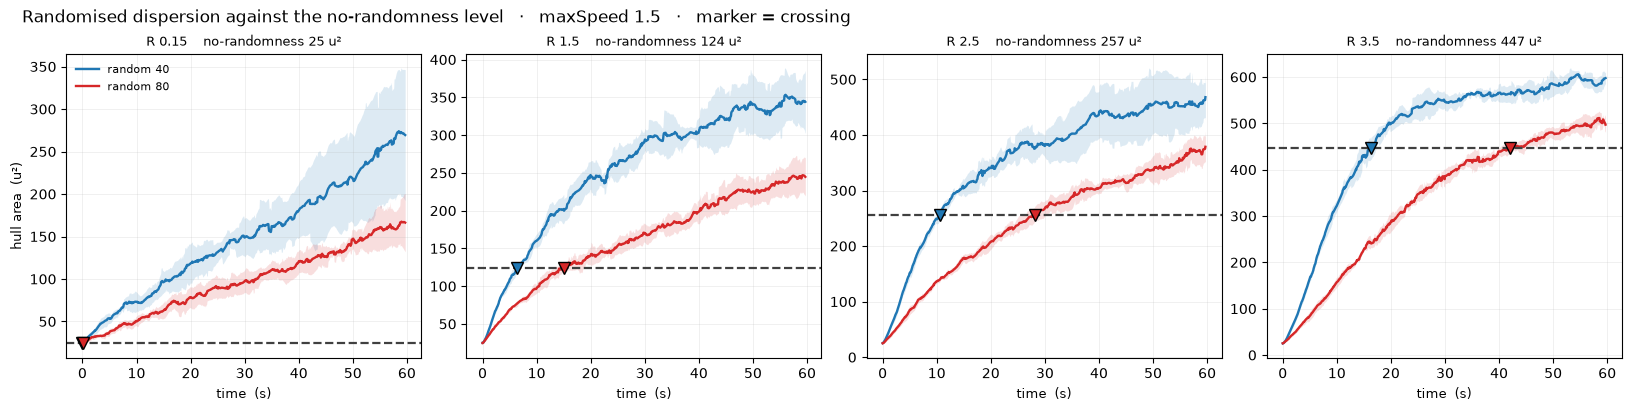

In [7]:
sst.reference_peak_figure(runs, SPEED)
plt.show()

In [8]:
rows = []
for R in RADII:
    refs = sst.select(runs, speed=SPEED, random=0, R=R)
    if not refs:
        continue
    level = np.mean([sst.run_statistic(r, "plateau")[0] for r in refs])
    start = np.mean([r["areas"][0] for r in refs])
    row = {"R": R, "no_randomness": round(level, 1), "growth_from_spawn": round(level / start, 2)}

    for rnd in [x for x in inv["randoms"] if x > 0]:
        sel = sst.select(runs, speed=SPEED, random=rnd, R=R)
        times = []
        for run in sel:
            c = ss.crossing_time(run, level, dwell=0.5, growing=level >= start)
            if c["fires"]:
                times.append(c["time"])
        row[f"r{rnd}_crosses_at_s"] = round(float(np.mean(times)), 1) if times else None
        row[f"r{rnd}_fires"] = f"{len(times)}/{len(sel)}"

    rows.append(row)

display(pd.DataFrame(rows))
print("A radius whose growth_from_spawn is near 1.0 has no usable level: the reference never moved.")

,R,no_randomness,growth_from_spawn,r40_crosses_at_s,r40_fires,r80_crosses_at_s,r80_fires
0,0.15,24.9,1.00,0.6,5/5,0.7,5/5
1,0.45,26.1,1.04,1.3,5/5,1.1,5/5
2,0.90,65.8,2.63,4.4,5/5,9.7,5/5
3,1.15,87.6,3.48,5.8,5/5,11.0,5/5
4,1.50,123.7,4.89,6.9,5/5,15.5,5/5
5,1.80,159.0,6.27,8.1,5/5,19.6,5/5
6,2.00,186.1,7.34,9.3,5/5,22.1,5/5
7,2.25,225.0,8.87,10.2,5/5,24.2,5/5
8,2.50,256.7,10.11,10.9,5/5,29.0,5/5
9,2.75,297.3,11.70,12.5,5/5,25.9,5/5


A radius whose growth_from_spawn is near 1.0 has no usable level: the reference never moved.


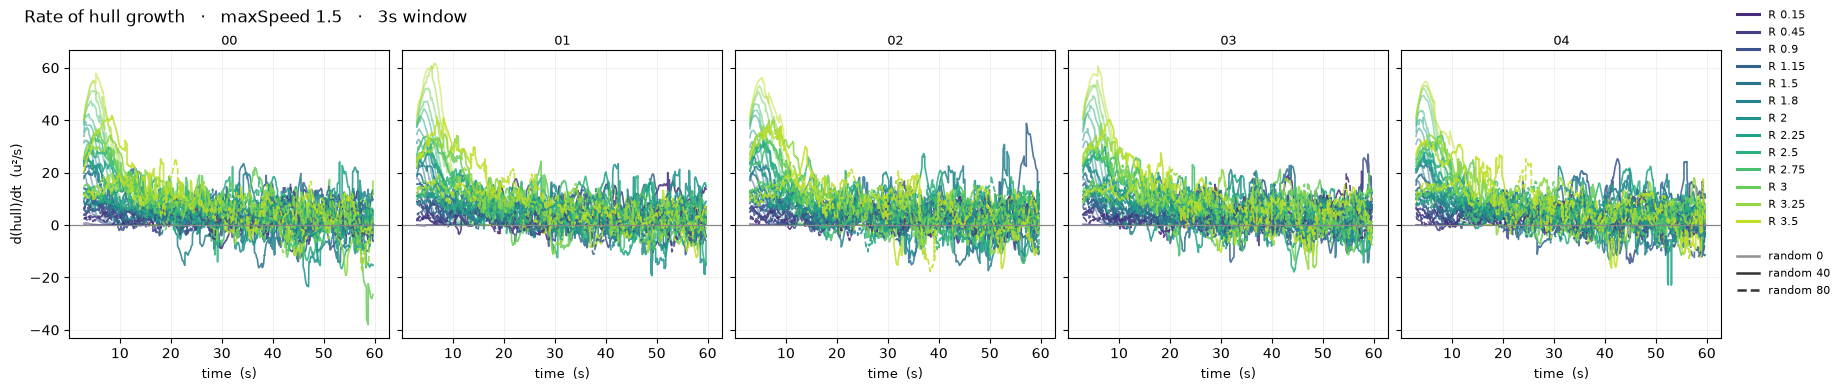

In [9]:
sst.rate_figure(runs, SPEED)
plt.show()

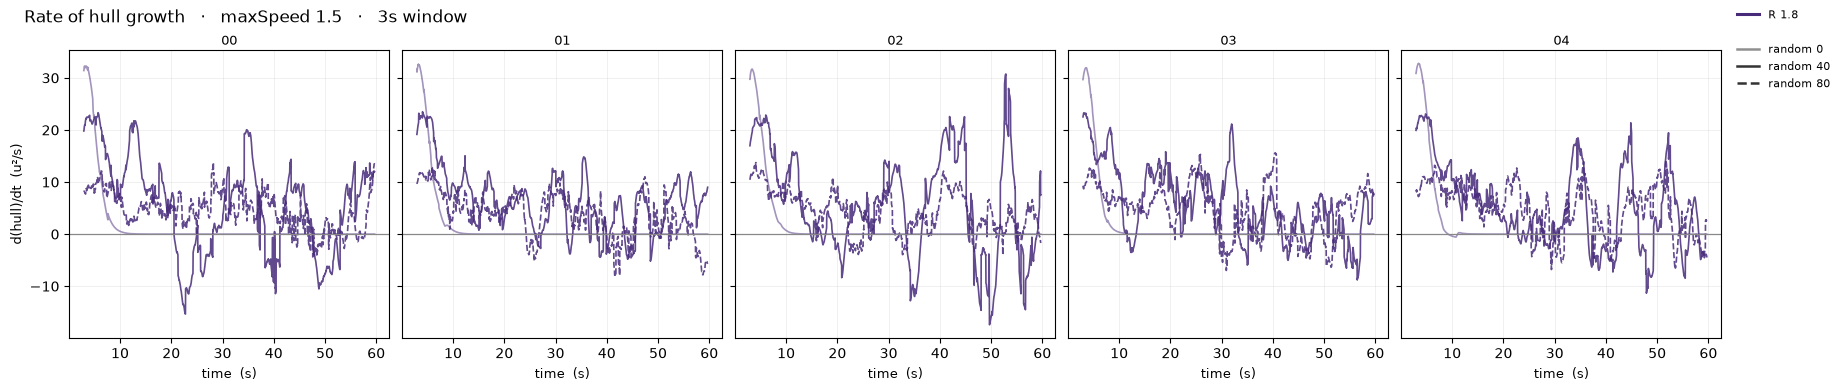

In [17]:
few = [R for R in (RADII[5], 100) if R in RADII]
sst.rate_figure(runs, SPEED, radii=few)
plt.show()

In [11]:
rows = []
for rnd in inv["randoms"]:
    for R in few:
        sel = sst.select(runs, speed=SPEED, random=rnd, R=R)
        if not sel:
            continue
        drift, noise, settled = [], [], []
        for r in sel:
            d = sst.savgol_drift(r["times"], r["areas"])
            late = r["times"] > r["times"][-1] - 20
            drift.append(d[late].mean())
            t, box = sst._smooth_derivative(r["times"], r["areas"], 1.0)
            noise.append(box[t > t[-1] - 20].std())
            settled.append(ss.find_plateau(r["times"], r["areas"])["reached"])
        rows.append({"R": R, "random": rnd,
                     "late_drift": round(float(np.mean(drift)), 2),
                     "late_noise_sd": round(float(np.mean(noise)), 2),
                     "SNR": round(float(np.mean(drift) / max(np.mean(noise), 1e-9)), 2),
                     "find_plateau_settled": f"{np.mean(settled):.0%}"})

display(pd.DataFrame(rows))

,R,random,late_drift,late_noise_sd,SNR,find_plateau_settled
0,0.90,0,-0.00,0.00,-0.00,100%
1,2.00,0,0.00,0.00,0.00,100%
2,3.25,0,-0.00,0.00,-0.00,100%
3,0.90,40,3.75,12.19,0.31,80%
4,2.00,40,2.50,17.82,0.14,20%
5,3.25,40,2.10,11.69,0.18,100%
6,0.90,80,2.04,7.71,0.26,40%
7,2.00,80,2.07,9.94,0.21,20%
8,3.25,80,2.67,9.47,0.28,80%


In [12]:
rows = []
for rnd in inv["randoms"]:
    for R in few:
        sel = sst.select(runs, speed=SPEED, random=rnd, R=R)
        if not sel:
            continue
        fired, times, after = 0, [], []
        for r in sel:
            d = sst.dispersion_end(r)
            if d["fires"]:
                fired += 1
                times.append(d["time"])
                after.append((r["areas"][-1] - r["areas"][d["index"]]) /
                             max(r["areas"][d["index"]], 1e-9))
        rows.append({"R": R, "random": rnd, "fires": f"{fired}/{len(sel)}",
                     "dispersion_ends_at_s": round(float(np.mean(times)), 1) if times else None,
                     "hull_grows_after": f"{np.mean(after):+.0%}" if after else None})

display(pd.DataFrame(rows))

,R,random,fires,dispersion_ends_at_s,hull_grows_after
0,0.90,0,5/5,3.6,+4%
1,2.00,0,5/5,6.1,+3%
2,3.25,0,5/5,10.2,+2%
3,0.90,40,5/5,30.2,+70%
4,2.00,40,5/5,29.8,+22%
5,3.25,40,5/5,27.8,+15%
6,0.90,80,4/5,24.2,+53%
7,2.00,80,5/5,37.3,+16%
8,3.25,80,4/5,34.2,+16%


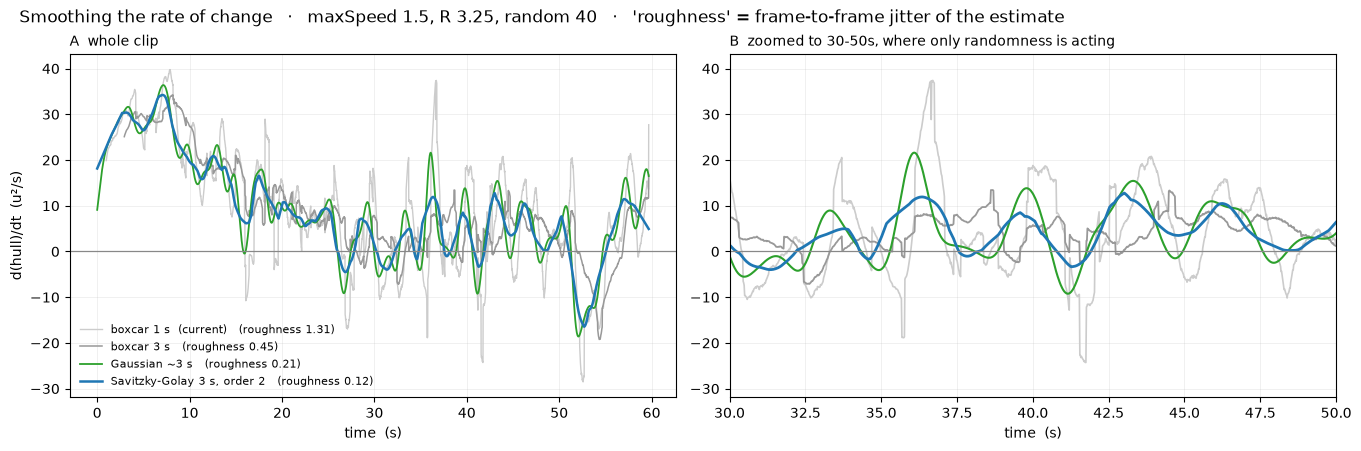

In [13]:
sst.smoothing_figure(runs, SPEED, radius=RADII[-2], random=40)
plt.show()

In [14]:
from scipy.ndimage import gaussian_filter1d

run = sst.select(runs, speed=SPEED, random=40, R=RADII[-2])[0]
t = np.asarray(run["times"]); a = np.asarray(run["areas"])
dt = float(np.median(np.diff(t)))

def boxcar(seconds):
    w = max(2, int(round(seconds / dt)))
    out = np.full(len(a), np.nan)
    out[w:] = (a[w:] - a[:-w]) / (t[w:] - t[:-w])
    return out

methods = {
    "boxcar 1 s (current)": boxcar(1.0),
    "boxcar 3 s": boxcar(3.0),
    "Gaussian ~3 s": gaussian_filter1d(a, sigma=(3.0 / dt) / 6.0, order=1, mode="nearest") / dt,
    "Savitzky-Golay 3 s order 2": sst.savgol_drift(t, a, 3.0, 2),
    "Savitzky-Golay 5 s order 3": sst.savgol_drift(t, a, 5.0, 3),
}

rows = []
for name, values in methods.items():
    tail = values[~np.isnan(values)][-1200:]
    rows.append({"method": name,
                 "late_mean": round(float(tail.mean()), 2),
                 "late_sd": round(float(tail.std()), 2),
                 "roughness": round(float(np.std(np.diff(tail))), 3)})

display(pd.DataFrame(rows).set_index("method"))
print("Same underlying drift, very different jitter. Savitzky-Golay 3 s is the cleanest.")

,late_mean,late_sd,roughness
method,,,
boxcar 1 s (current),2.92,11.30,1.311
boxcar 3 s,2.42,6.62,0.453
Gaussian ~3 s,3.01,8.94,0.206
Savitzky-Golay 3 s order 2,2.58,7.20,0.117
Savitzky-Golay 5 s order 3,2.64,8.08,0.145


Same underlying drift, very different jitter. Savitzky-Golay 3 s is the cleanest.
